In [1]:
# ── Google Colab setup ────────────────────────────────────────────────────────
# Run this cell first when opening the notebook in Google Colab.
# On a local machine all conditions are False and nothing executes.

import os, sys

try:
    IN_COLAB = 'google.colab' in str(get_ipython())
except Exception:
    IN_COLAB = False

if IN_COLAB:
    !git clone https://github.com/IvankaiKrisztian/Szakdolgozat.git
    os.chdir('Szakdolgozat/data')
    sys.path.insert(0, '/content/Szakdolgozat')
    # Pin package versions to match local environment and ensure reproducible scores
    !pip install -q "numpy==2.4.2" "pandas==3.0.1" "holidays==0.93"

In [2]:
import sys

if not IN_COLAB:
    sys.path.append("/Users/krisztianivankai/PycharmProjects/Szakdolgozat/")

from models.fuzzy import *
from models.moving_average import forecast_moving_average
from utilities.utils import *
from evaluate.evaluate_model import get_model_score
from forecast.forecast import forecast_over_horizon, explain_forecast

## 1. Imports and Global Settings

Project-local modules imported:
- `models.fuzzy`: fuzzy set classes and forecasting functions
- `models.moving_average`: moving average baseline model
- `utilities.utils`: data preparation and visualisation helpers
- `evaluate.evaluate_model`: Vandeput score computation
- `forecast.forecast`: walk-forward forecasting pipeline

`sys.path.append` is required so the notebook can resolve project-root-level modules.

# Fuzzy Time-Series Demand Forecasting — Main Analysis

This notebook runs the full experimental pipeline for the fuzzy time-series demand forecasting model and benchmarks it against a 7-day moving average baseline.

**Notebook structure:**
1. Data loading and exploratory analysis
2. Demand preparation (interpolation, stockout handling)
3. Fuzzy set definitions
4. Rule base construction (training)
5. Walk-forward forecasting with both models
6. Evaluation and comparison of results

In [3]:
sales_and_stock = pd.read_csv('Szakdoga_adat.csv')
split_percentage = 0.8
lags_to_use = 7

## 2. Data Loading and Global Parameters

`Szakdoga_adat.csv` contains 789 rows of daily sales and stock data (2024-01-01 to 2026-02-27).

**Parameters:**
- `split_percentage = 0.8`: 80/20 chronological train/test split
- `lags_to_use = 7`: the fuzzy model receives the 7 most recent daily demand values as input features

In [4]:
holidays_df = get_holidays_df()

In [5]:
get_date_features(sales_and_stock)

,date,sales,stock,day_of_week,month,quarter,year,year_quarter
0,2024-01-01,NaN,32,0,1,1,2024,2024Q1
1,2024-01-02,10.0,22,1,1,1,2024,2024Q1
2,2024-01-03,13.0,9,2,1,1,2024,2024Q1
3,2024-01-04,25.0,34,3,1,1,2024,2024Q1
4,2024-01-05,27.0,7,4,1,1,2024,2024Q1
...,...,...,...,...,...,...,...,...
784,2026-02-23,76.0,335,0,2,1,2026,2026Q1
785,2026-02-24,74.0,261,1,2,1,2026,2026Q1
786,2026-02-25,66.0,195,2,2,1,2026,2026Q1
787,2026-02-26,55.0,140,3,2,1,2026,2026Q1


## 3. Exploratory Data Analysis (EDA)

### 3.1 Date Feature Extraction

`get_date_features()` derives temporal features from the date column: day of week, month, quarter, year, and year-quarter. These are used solely for EDA visualisations; none are passed to the model.

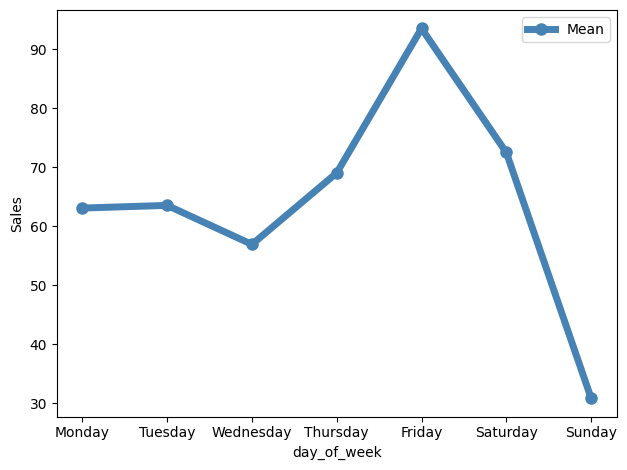

In [6]:
plot_average_by_group(sales_and_stock, 'day_of_week',0,True)

### 3.2 Sales by Temporal Group

Average sales grouped by month, day of week, year-quarter, and year — used to identify seasonal and weekly demand patterns.

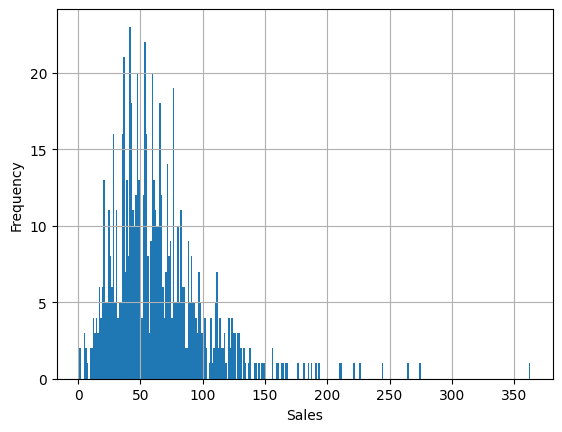

In [7]:
sales_and_stock["sales"].hist(bins=300)#,figsize=(10,10))
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

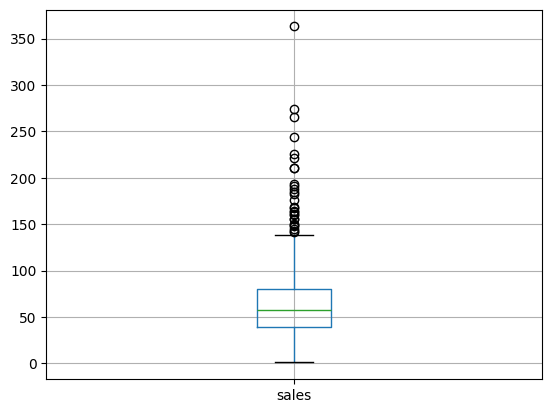

In [8]:
sales_and_stock.boxplot(column="sales")
plt.show()

In [9]:
calculate_adi(sales_and_stock)

np.float64(1.0)

### 3.3 Demand Classification: ADI and CV²

- **ADI = 1.0**: demand occurs every day (continuous demand pattern)
- **CV² ≈ 0.60**: moderate variability

Under the Syntetos-Boylan classification, ADI ≈ 1.0 and CV² < 0.49 threshold places this series in the "smooth" category — making it well-suited for pattern-based forecasting.

In [10]:
calculate_cv(sales_and_stock)

np.float64(0.5981896621713417)

In [11]:
demand = get_prepared_demand_df(sales_and_stock)
demand = demand[~demand['date'].isin(holidays_df['date'])]

## 4. Demand Preparation

`get_prepared_demand_df()` addresses two issues in the raw data:
1. **Missing dates**: the full date range is materialised so there are no gaps.
2. **Stockout days**: on days where `stock = 0`, recorded sales understate true demand. Demand on those days is estimated via **linear interpolation**.

Public holidays are then excluded via an anti-join (`left_anti`), as holiday demand patterns would distort the rule base learned from normal trading days.

In [12]:
demand[['demand']].describe()

,demand
count,762.000000
mean,64.130577
std,38.087063
min,0.000000
25%,40.000000
50%,58.000000
75%,80.000000
max,363.000000


In [13]:
demand[['demand']].skew()

demand    2.002321
dtype: float64

In [14]:
demand[['demand']].kurtosis()

demand    8.320434
dtype: float64

In [15]:
calculate_adi(demand,'demand')

np.float64(1.0026315789473683)

In [16]:
calculate_cv(demand,'demand')

np.float64(0.5938986450650299)

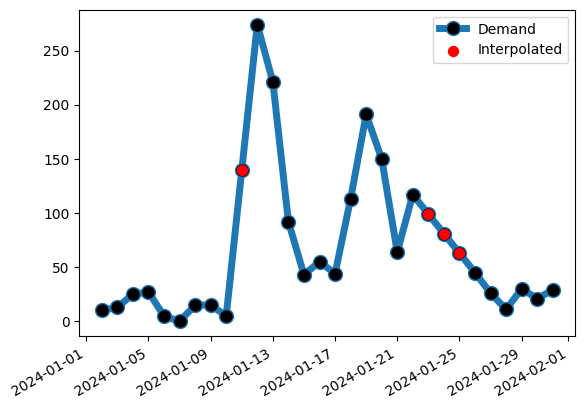

In [17]:
plot_imputed_values_with_missing_stock(demand.head(30))

In [18]:
split_date = get_split_date(sales_and_stock, split_percentage)
train_data = demand[demand['date'] < split_date].reset_index(drop=True)
test_data = demand[demand['date'] >= (split_date - timedelta(days=lags_to_use))].reset_index(drop=True)[['date','demand']]

In [19]:
train_data

,date,sales,stock,day_of_week,month,quarter,year,year_quarter,out_of_stock,demand
0,2024-01-02,10.0,22,1,1,1,2024,2024Q1,False,10.000000
1,2024-01-03,13.0,9,2,1,1,2024,2024Q1,False,13.000000
2,2024-01-04,25.0,34,3,1,1,2024,2024Q1,False,25.000000
3,2024-01-05,27.0,7,4,1,1,2024,2024Q1,False,27.000000
4,2024-01-06,5.0,2,5,1,1,2024,2024Q1,False,5.000000
...,...,...,...,...,...,...,...,...,...,...
603,2025-09-17,58.0,79,2,9,3,2025,2025Q3,False,58.000000
604,2025-09-18,58.0,21,3,9,3,2025,2025Q3,False,58.000000
605,2025-09-19,62.0,59,4,9,3,2025,2025Q3,False,62.000000
606,2025-09-20,44.0,15,5,9,3,2025,2025Q3,False,44.000000


In [20]:
test_data

,date,demand
0,2025-09-15,52.0
1,2025-09-16,59.0
2,2025-09-17,58.0
3,2025-09-18,58.0
4,2025-09-19,62.0
...,...,...
156,2026-02-23,76.0
157,2026-02-24,74.0
158,2026-02-25,66.0
159,2026-02-26,55.0


In [21]:
split_date

Timestamp('2025-09-22 00:00:00')

## 5. Train / Test Split

The dataset is split **chronologically** (80% train, 20% test). The test set retains the last `lags_to_use` rows from the training period as a warm-up window, since generating the first forecast requires `lags_to_use` historical observations as input.

In [22]:
statistics = train_data[['demand']].describe()

In [23]:
statistics

,demand
count,608.000000
mean,64.120614
std,38.860872
min,0.000000
25%,39.000000
50%,58.000000
75%,80.000000
max,363.000000


In [24]:
demand_min = 0 #statistics.T["min"].to_list()[0]
demand_first_quartile = 25#statistics.T["25%"].to_list()[0]
demand_median = 50#statistics.T["50%"].to_list()[0]
demand_third_quartile = 100#statistics.T["75%"].to_list()[0]
demand_max = 500#statistics.T["max"].to_list()[0]

## 6. Fuzzy Set Definitions

Five linguistic categories are defined to partition the demand universe. Partition boundaries are fixed at round-number approximations of the training-set quartiles:

| Set name        | Type             | Support        |
|-----------------|------------------|----------------|
| VeryLowDemand   | Left shoulder    | 0 – 25         |
| LowDemand       | Triangular       | 0 – 25 – 50    |
| MediumDemand    | Triangular       | 25 – 50 – 100  |
| HighDemand      | Triangular       | 50 – 100 – 500 |
| VeryHighDemand  | Right shoulder   | 100 – 500      |

Shoulder sets at both ends of the partition guarantee full membership (μ = 1) for extreme values, preventing the boundary regions from being under-represented in the rule base.

In [25]:
fuzzy_sets = [
    {
        "name": "VeryLowDemand",
        "type": "shoulder",
        "a": demand_min,
        "b": demand_first_quartile,
        "direction": "left",
    },
    {
        "name": "LowDemand",
        "type": "triangular",
        "a": demand_min,
        "b": demand_first_quartile,
        "c": demand_median,
    },
    {
        "name": "MediumDemand",
        "type": "triangular",
        "a": demand_first_quartile,
        "b": demand_median,
        "c": demand_third_quartile,
    },
    {
        "name": "HighDemand",
        "type": "triangular",
        "a": demand_median,
        "b": demand_third_quartile,
        "c": demand_max
    },
    {
        "name": "VeryHighDemand",
        "type": "shoulder",
        "a": demand_third_quartile,
        "b": demand_max,
        "direction": "right"
    }
]

In [26]:
train_data[train_data['date']<='2024-01-11']

,date,sales,stock,day_of_week,month,quarter,year,year_quarter,out_of_stock,demand
0,2024-01-02,10.0,22,1,1,1,2024,2024Q1,False,10.0
1,2024-01-03,13.0,9,2,1,1,2024,2024Q1,False,13.0
2,2024-01-04,25.0,34,3,1,1,2024,2024Q1,False,25.0
3,2024-01-05,27.0,7,4,1,1,2024,2024Q1,False,27.0
4,2024-01-06,5.0,2,5,1,1,2024,2024Q1,False,5.0
5,2024-01-07,NaN,2,6,1,1,2024,2024Q1,False,0.0
6,2024-01-08,15.0,187,0,1,1,2024,2024Q1,False,15.0
7,2024-01-09,15.0,172,1,1,1,2024,2024Q1,False,15.0
8,2024-01-10,5.0,167,2,1,1,2024,2024Q1,False,5.0
9,2024-01-11,210.0,0,3,1,1,2024,2024Q1,True,139.5


In [27]:
rule_base = create_rule_base_df(train_data, lags_to_use, fuzzy_sets)

In [28]:
rule_base

,lag_1_fuzzy_set,lag_2_fuzzy_set,lag_3_fuzzy_set,lag_4_fuzzy_set,lag_5_fuzzy_set,lag_6_fuzzy_set,lag_7_fuzzy_set,demand
0,HighDemand,HighDemand,HighDemand,HighDemand,HighDemand,HighDemand,MediumDemand,42.0
1,HighDemand,HighDemand,HighDemand,HighDemand,HighDemand,LowDemand,MediumDemand,69.0
2,HighDemand,HighDemand,HighDemand,HighDemand,HighDemand,MediumDemand,HighDemand,82.0
3,HighDemand,HighDemand,HighDemand,HighDemand,LowDemand,MediumDemand,HighDemand,125.0
4,HighDemand,HighDemand,HighDemand,HighDemand,MediumDemand,HighDemand,HighDemand,94.5
...,...,...,...,...,...,...,...,...
413,VeryLowDemand,LowDemand,MediumDemand,MediumDemand,MediumDemand,HighDemand,HighDemand,43.0
414,VeryLowDemand,LowDemand,MediumDemand,MediumDemand,MediumDemand,LowDemand,LowDemand,16.0
415,VeryLowDemand,LowDemand,MediumDemand,MediumDemand,MediumDemand,MediumDemand,MediumDemand,25.0
416,VeryLowDemand,MediumDemand,HighDemand,MediumDemand,MediumDemand,MediumDemand,MediumDemand,45.0


## 7. Rule Base Construction (Training)

`create_rule_base_df()` builds the fuzzy rule base from the training data:

1. Each daily demand value is assigned to its closest fuzzy set (e.g. 65 units → "MediumDemand").
2. Lag-L input–output pairs are constructed: the fuzzy labels of the preceding L days form the antecedent; the next day's demand is the consequent.
3. Rows sharing the same antecedent are averaged — the mean consequent becomes the rule output.

With L = 7, the resulting rule base contains 418 unique rules.

In [29]:
fuzz_cols = [f'lag_{i}_fuzzy_set' for i in range(1, lags_to_use+1)]

fuzzy_statistics = []

for fuzz_col in fuzz_cols:
    fuzzy_statistics.append(rule_base.groupby([fuzz_col])[[fuzz_col]].count())

pd.concat(fuzzy_statistics,axis=1)

,lag_1_fuzzy_set,lag_2_fuzzy_set,lag_3_fuzzy_set,lag_4_fuzzy_set,lag_5_fuzzy_set,lag_6_fuzzy_set,lag_7_fuzzy_set
HighDemand,138,133,127,126,126,126,134
LowDemand,88,92,91,96,103,101,98
MediumDemand,181,181,187,184,177,179,173
VeryHighDemand,1,1,1,1,1,1,1
VeryLowDemand,10,11,12,11,11,11,12


In [30]:
lingustic_rules = get_linguistic_form(rule_base)

### 7.1 Rules in Linguistic Form

`get_linguistic_form()` renders each rule as an IF-THEN statement, e.g.:

> IF LAG 1 demand IS MediumDemand AND LAG 2 demand IS HighDemand AND ... THEN 72.5

This representation is used for explainability output in Section 10.

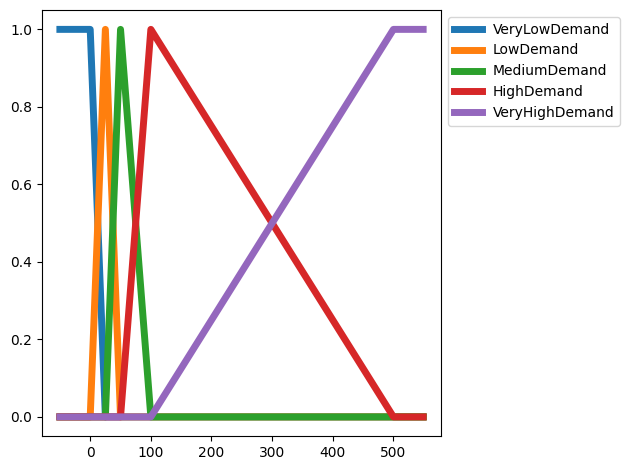

In [31]:
plot_fuzzy_sets_memberships(fuzzy_sets,demand_min,demand_max)

In [32]:
test_data = test_data[~test_data['date'].isin(holidays_df['date'])]

In [33]:
validation_start_date = test_data['date'].min() + timedelta(days=lags_to_use)
forecast_horizon = (test_data['date'].max() - validation_start_date).days + 1
moving_average_forecast = forecast_over_horizon(test_data,validation_start_date,forecast_horizon,lags_to_use,forecast_moving_average,[lags_to_use])

## 8. Walk-Forward Forecasting

`forecast_over_horizon()` executes a strict walk-forward evaluation: for each target day t, only the L actual observations prior to t are used as input — no future data leaks into any forecast.

**Procedure per step:**
1. Extract the L most recent realised demand values (t−L … t−1).
2. Pass them to the forecasting function (fuzzy pipeline or moving average).
3. Store the point forecast and the inference trace.
4. Advance to t+1 and repeat.

In [34]:
log_stream = log_not_fired_rules()

### 8.1 Logging Non-Firing Rule Events

`log_not_fired_rules()` initialises a logging buffer. If during inference no rule in the base has a firing strength greater than zero, the event is recorded. The total count of such cases is reported after the forecast run completes.

In [35]:
fuzzy_model_forecast = forecast_over_horizon(test_data, validation_start_date, forecast_horizon,lags_to_use, fuzzy_forecast_pipeline, [fuzzy_sets, rule_base])

DEBUG:root:Forecasted for: 2025-09-22 00:00:00
DEBUG:root:Forecasted for: 2025-09-23 00:00:00
DEBUG:root:Forecasted for: 2025-09-24 00:00:00
DEBUG:root:Forecasted for: 2025-09-25 00:00:00
DEBUG:root:Forecasted for: 2025-09-26 00:00:00
DEBUG:root:Forecasted for: 2025-09-27 00:00:00
DEBUG:root:Forecasted for: 2025-09-28 00:00:00
DEBUG:root:Forecasted for: 2025-09-29 00:00:00
DEBUG:root:Forecasted for: 2025-09-30 00:00:00
DEBUG:root:Forecasted for: 2025-10-01 00:00:00
DEBUG:root:Forecasted for: 2025-10-02 00:00:00
DEBUG:root:Forecasted for: 2025-10-03 00:00:00
DEBUG:root:Forecasted for: 2025-10-04 00:00:00
DEBUG:root:Forecasted for: 2025-10-05 00:00:00
DEBUG:root:Forecasted for: 2025-10-06 00:00:00
DEBUG:root:Forecasted for: 2025-10-07 00:00:00
DEBUG:root:Forecasted for: 2025-10-08 00:00:00
DEBUG:root:Forecasted for: 2025-10-09 00:00:00
DEBUG:root:Forecasted for: 2025-10-10 00:00:00
DEBUG:root:Forecasted for: 2025-10-11 00:00:00
DEBUG:root:Forecasted for: 2025-10-12 00:00:00
DEBUG:root:Fo

In [36]:
log_output = log_stream.getvalue()
count = log_output.count("Rule not fired!")
print(f"Rule not fired: {count} times, that is {round(count/fuzzy_model_forecast.count().max()*100,2)}% of days")
print(f"It worked in {fuzzy_model_forecast.count().max()-count} times, which is {100-round(count/fuzzy_model_forecast.count().max()*100,2)}% of days")

Rule not fired: 13 times, that is 8.18% of days
It worked in 146 times, which is 91.82% of days


### 8.2 Non-Firing Summary

At least one rule fired in **91.82%** of forecasting steps. In the remaining 8.18% (13 days) no rule matched the input pattern; the fallback strategy returns the unweighted mean of all rule consequents.

In [37]:
test_data = test_data[test_data['date']>= validation_start_date]

In [38]:
fuzzy_model_forecast.to_csv("fuzzy_model_forecast.csv")

In [39]:
fuzzy_model_forecast

,date,prediction,explanation
0,2025-09-22,51.438676,lag_1_fuzzy_set lag_2_fuzzy_set lag_3_fuzz...
0,2025-09-23,49.576075,lag_1_fuzzy_set lag_2_fuzzy_set lag_3_fuzz...
0,2025-09-24,52.180219,lag_1_fuzzy_set lag_2_fuzzy_set lag_3_fuzz...
0,2025-09-25,52.998454,lag_1_fuzzy_set lag_2_fuzzy_set lag_3_fuzz...
0,2025-09-26,53.139458,lag_1_fuzzy_set lag_2_fuzzy_set lag_3_fuzz...
...,...,...,...
0,2026-02-23,61.653993,lag_1_fuzzy_set lag_2_fuzzy_set lag_3_fuzz...
0,2026-02-24,72.511954,lag_1_fuzzy_set lag_2_fuzzy_set lag_3_fuzz...
0,2026-02-25,64.406310,lag_1_fuzzy_set lag_2_fuzzy_set lag_3_fuzz...
0,2026-02-26,60.111324,lag_1_fuzzy_set lag_2_fuzzy_set lag_3_fuzz...


## 9. Persisting Forecast Results

Both forecast DataFrames (date, predicted value, inference trace) are written to CSV files in the `data/` directory so downstream analysis can reload them without re-running the full pipeline.

In [40]:
moving_average_forecast.to_csv("moving_average_forecast.csv")

'2025-10-27'

In [41]:
fuzzy_model_forecast['rules_fired'] = fuzzy_model_forecast['explanation'].apply(len)

In [42]:
fuzzy_model_forecast[fuzzy_model_forecast['rules_fired']==3]

,date,prediction,explanation,rules_fired
0,2026-01-17,105.863636,lag_1_fuzzy_set lag_2_fuzzy_set lag_3_fuzz...,3
0,2026-01-18,51.522727,lag_1_fuzzy_set lag_2_fuzzy_set lag_3_fuzzy...,3
0,2026-01-19,71.165904,lag_1_fuzzy_set lag_2_fuzzy_set lag_3_fuzz...,3
0,2026-01-30,50.238582,lag_1_fuzzy_set lag_2_fuzzy_set lag_3_fuzz...,3


In [43]:
test_data[test_data['date'].between('2026-01-10','2026-01-17')]

,date,demand
112,2026-01-10,55.0
113,2026-01-11,21.0
114,2026-01-12,65.0
115,2026-01-13,35.0
116,2026-01-14,25.0
117,2026-01-15,95.0
118,2026-01-16,156.0
119,2026-01-17,117.0


In [44]:
explain_forecast(fuzzy_model_forecast, '2026-01-17')

,lag_1_fuzzy_set,lag_2_fuzzy_set,lag_3_fuzzy_set,lag_4_fuzzy_set,lag_5_fuzzy_set,lag_6_fuzzy_set,lag_7_fuzzy_set,demand,lag_1_membership,lag_2_membership,lag_3_membership,lag_4_membership,lag_5_membership,lag_6_membership,lag_7_membership,firing_strength,rule_prediction,linguistic_form,demand_as_string
32,HighDemand,HighDemand,LowDemand,LowDemand,MediumDemand,VeryLowDemand,MediumDemand,138.0,0.86,0.9,1.0,0.6,0.7,0.16,0.9,0.046812,6.459990,IF LAG 1 demand IS HighDemand AND LAG 2 demand...,138.0
34,HighDemand,HighDemand,LowDemand,MediumDemand,MediumDemand,LowDemand,MediumDemand,100.0,0.86,0.9,1.0,0.4,0.7,0.84,0.9,0.163840,16.384032,IF LAG 1 demand IS HighDemand AND LAG 2 demand...,100.0
108,HighDemand,MediumDemand,LowDemand,MediumDemand,MediumDemand,LowDemand,MediumDemand,76.0,0.86,0.1,1.0,0.4,0.7,0.84,0.9,0.018204,1.383540,IF LAG 1 demand IS HighDemand AND LAG 2 demand...,76.0


## 10. Forecast Explainability

`explain_forecast()` returns, for a given date, every rule that fired during that inference step. Each row in the output corresponds to one fired rule:
- `lag_X_fuzzy_set`: the fuzzy label assigned to the demand value X days prior
- `lag_X_membership`: the degree of membership of lag X in that set
- `firing_strength`: the conjunction of all lag memberships (product t-norm)
- `rule_prediction`: the weighted contribution of this rule to the final forecast (firing_strength × consequent)
- `linguistic_form`: the rule in human-readable IF-THEN format

The defuzzified forecast is the sum of `rule_prediction` values divided by the total firing strength across all fired rules.

In [45]:
filtered_test_data = test_data[test_data['date']<='2025-10-22']
filtered_fuzzy_data = fuzzy_model_forecast[fuzzy_model_forecast['date']<='2025-10-22']
filtered_average_data = moving_average_forecast[moving_average_forecast['date']<='2025-10-22']

DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=50.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/krisztianivankai/PycharmProjects/Szakdolgozat/.venv/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymReg.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/krisztianivankai/PycharmProjects/Szakdolgozat/.venv/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/STIXGeneralBolIta.ttf', name='STIXGeneral', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/krisztianivankai/PycharmProjects/Szakdolgozat/.venv/lib/python3.13/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif-Italic.ttf', name='DejaVu Serif', style='ital

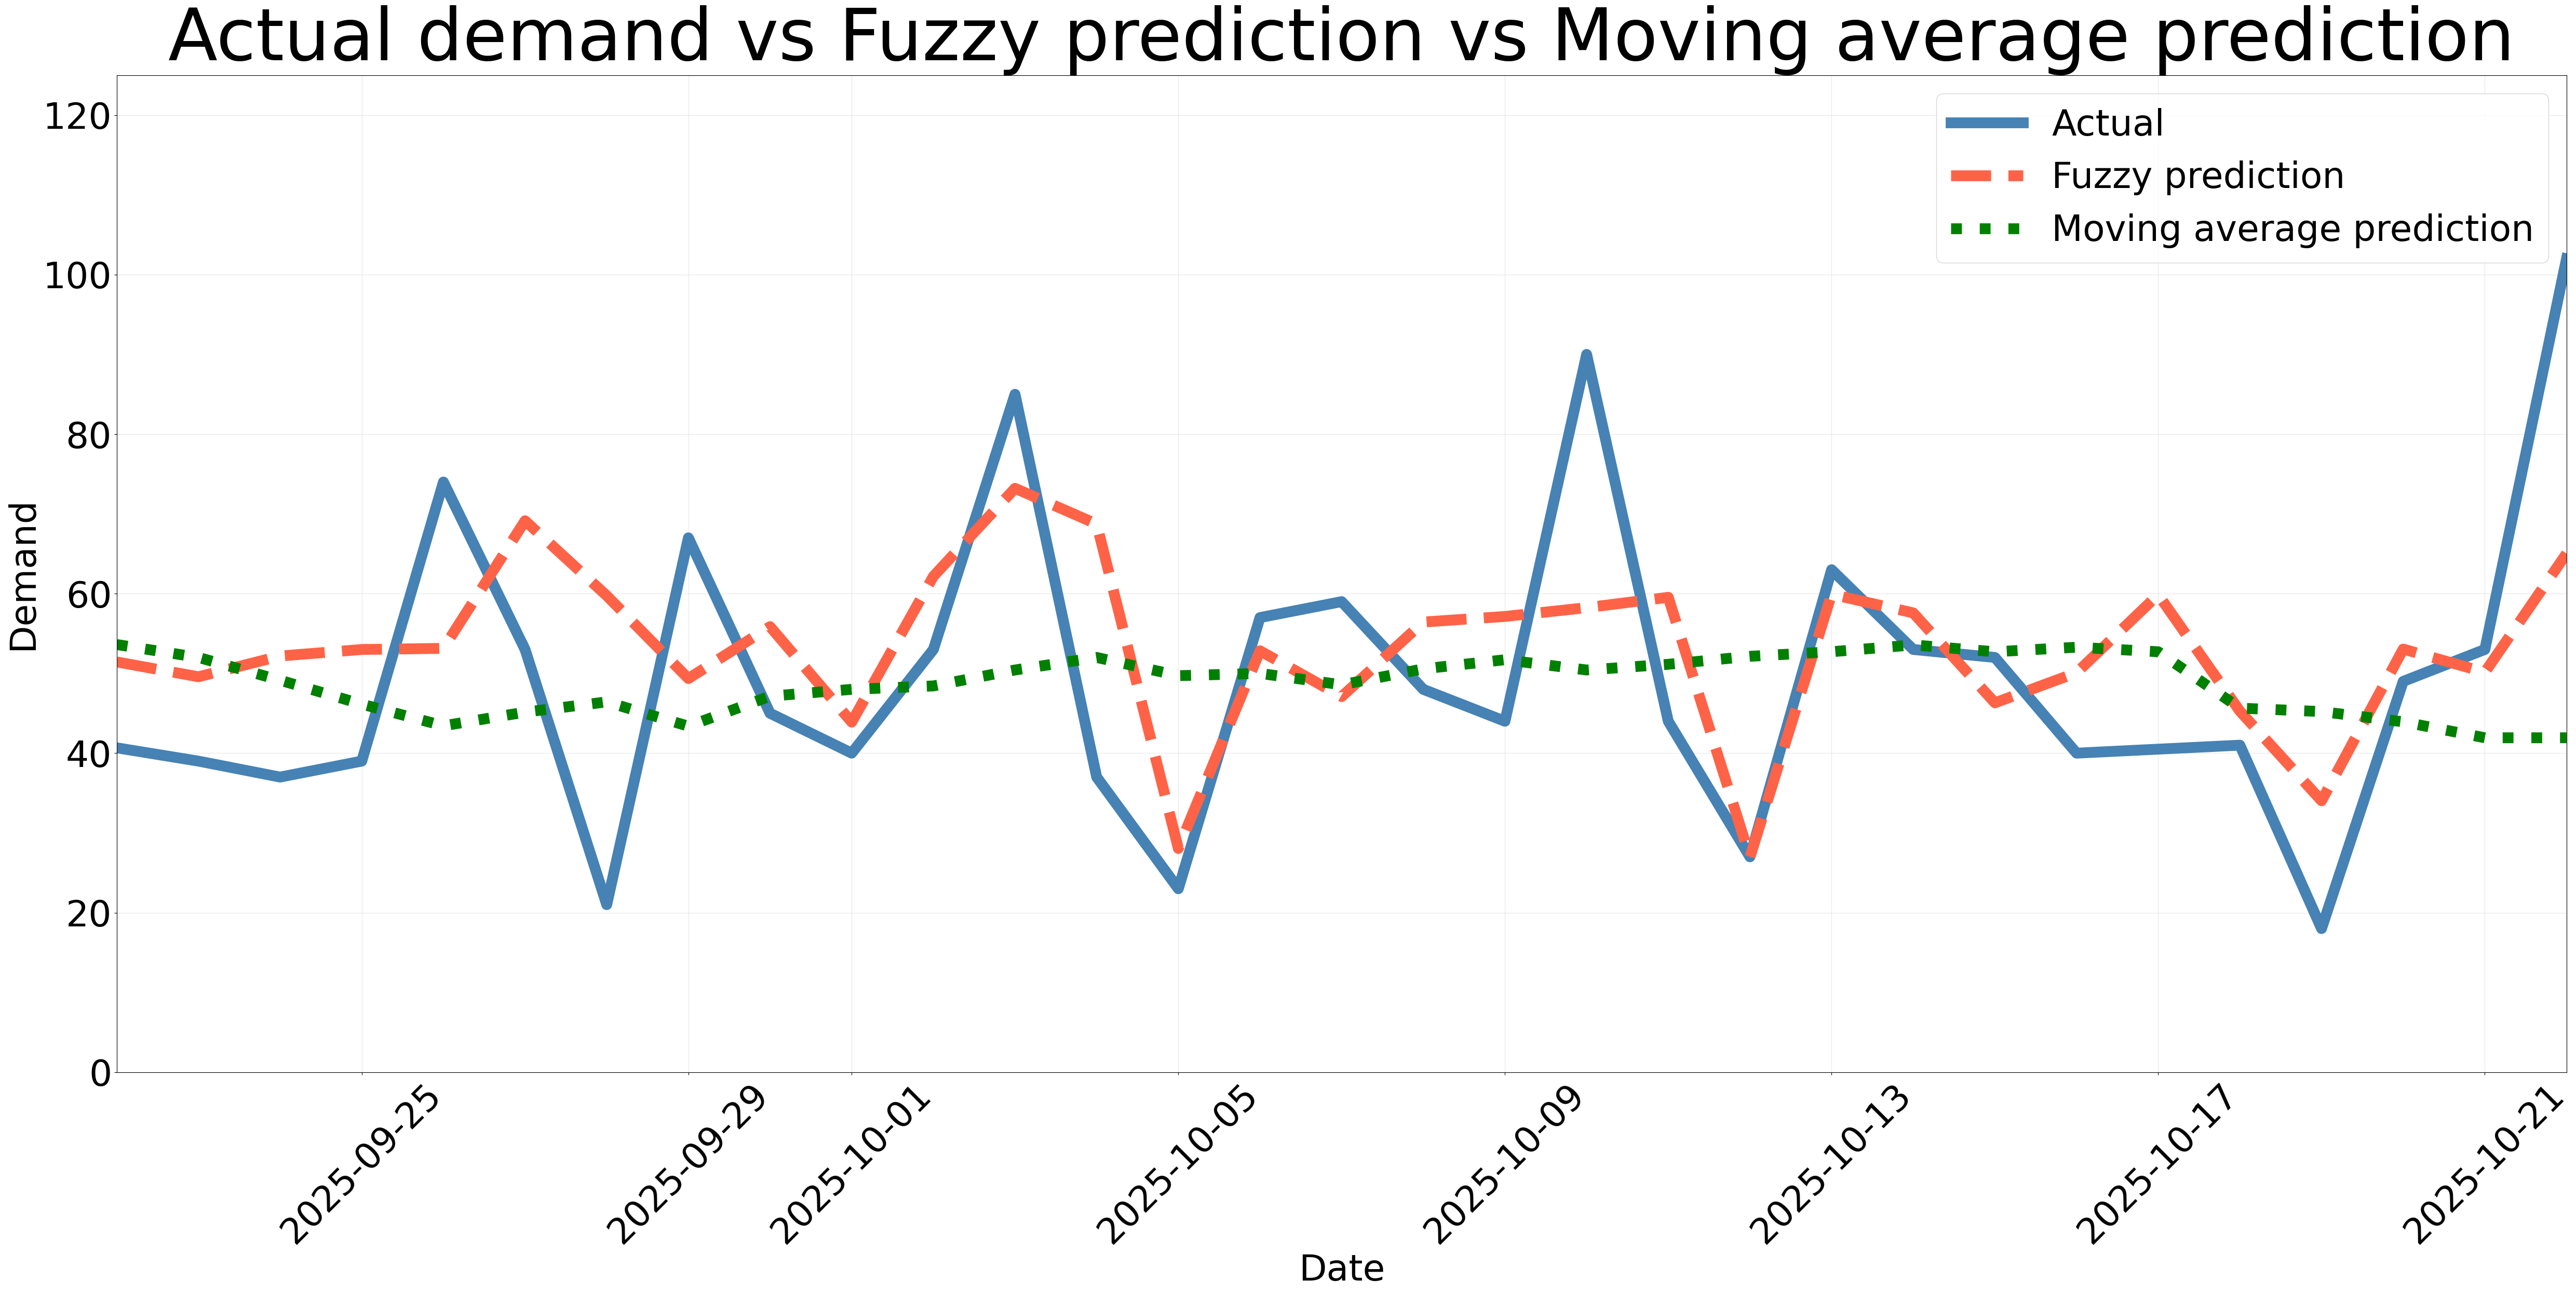

In [46]:
plot_actual_demand_and_2_prediction_model(filtered_test_data, filtered_fuzzy_data, filtered_average_data)

In [47]:
fuzzy_score = get_model_score(test_data, fuzzy_model_forecast)
moving_average_score = get_model_score(test_data, moving_average_forecast)

## 11. Evaluation — Vandeput Score

`get_model_score()` computes the aggregate performance metrics for both models.

**Metrics:**
- **MAE**: mean absolute error in demand units
- **MAE%**: MAE normalised by mean demand (scale-independent)
- **Bias**: systematic over- or under-forecasting (positive = over-forecast)
- **Bias%**: Bias normalised by mean demand
- **Score = MAE% + |Bias%|**: composite score — lower is better

In [48]:
fuzzy_score

,mae,mae_pct,bias,bias_pct,score
0,21.482079,0.334769,-0.763062,-0.011891,0.34666


### 11.1 Fuzzy Model Results

Fuzzy model score: **0.347** (MAE% ≈ 33.5%, Bias% ≈ −1.2%).

In [49]:
moving_average_score

,mae,mae_pct,bias,bias_pct,score
0,26.265306,0.409309,-0.310451,-0.004838,0.414147


### 11.2 Moving Average (Baseline) Results and Comparison

Moving average score: **0.414** (MAE% ≈ 40.9%, Bias% ≈ −0.5%).

**Summary:**
| Model           | Score | MAE   | MAE%  |
|-----------------|-------|-------|-------|
| Fuzzy model     | 0.347 | 21.48 | 33.5% |
| Moving average  | 0.414 | 26.27 | 40.9% |

The fuzzy model achieves a **~16% lower composite score** than the moving average baseline, confirming the viability of the fuzzy time-series approach for demand forecasting.